In [7]:
!pip install opencv-python
!pip install opencv-python-headless
!pip install -U ultralytics

import cv2

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 9.7 MB/s  0:00:00
   ---------------------------------------- 0.0/837.6 kB ? eta -:--:--
   ---------------------------------------- 837.6/837.6 kB 8.6 MB/s  0:00:00
   ---------------------------------------- 0.0/52.7 MB ? eta -:--:--
   -- ------------------------------------- 2.9/52.7 MB 13.3 MB/s eta 0:00:04
   ---- ----------------------------------- 5.8/52.7 MB 13.2 MB/s eta 0:00:04
   ------ --------------------------------- 8.7/52.7 MB 13.2 MB/s eta 0:00:04
   -------- ------------------------------- 11.5/52.7 MB 13.1 MB/s eta 0:00:04
   ---------- ----------------------------- 14.4/52.7 MB 13.2 MB/s eta 0:00:03
   ------------ --------------------------- 17.0/52.7 MB 13.2 MB/s eta 0:00:03
   --------------- ------------------------ 19.9/52.7 MB 13.1 MB/s eta 0:00:03
   ---------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Imports OK

1. TEST DU DÉTECTEUR YOLO
 Loading model yolov8n.pt...
Model loaded (80 classes)
✅ Modèle chargé en 0.50s
   Classes disponibles: 80
   Premières classes: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']

2. TEST SUR IMAGE DE SIMULATION

0: 480x640 (no detections), 6543.5ms
Speed: 123.7ms preprocess, 6543.5ms inference, 6.0ms postprocess per image at shape (1, 3, 480, 640)
⏱️ Temps d'inférence: 7879.5ms
📊 Nombre d'objets détectés: 0


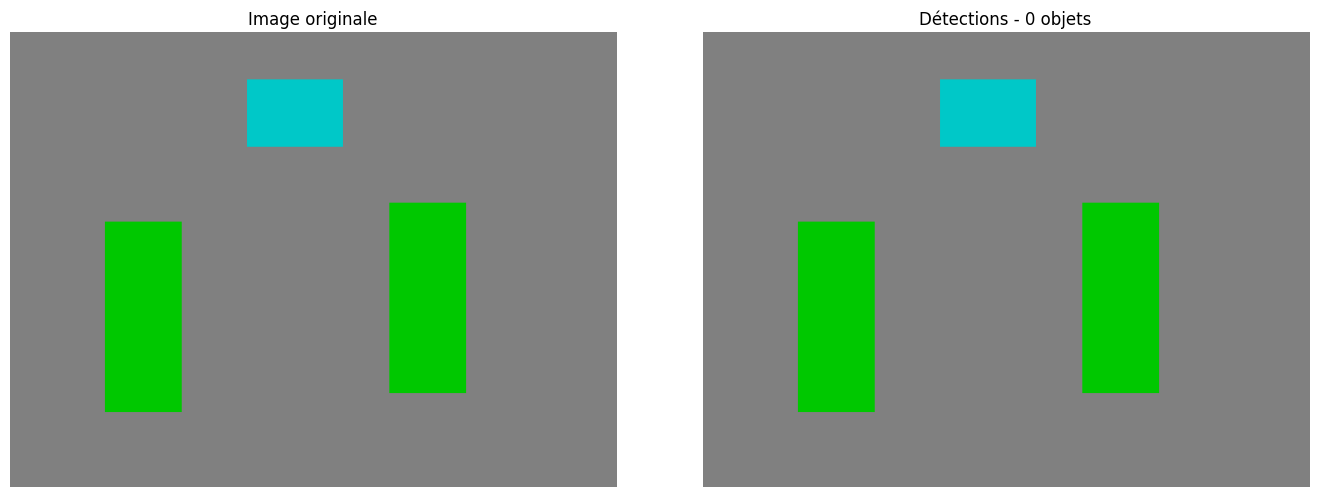


3. TEST DU SYSTÈME D'ALARME
🚨 Alarme (personnes proches): True
👤 Nombre de personnes: 2
🚨 Alarme (personnes éloignées): False


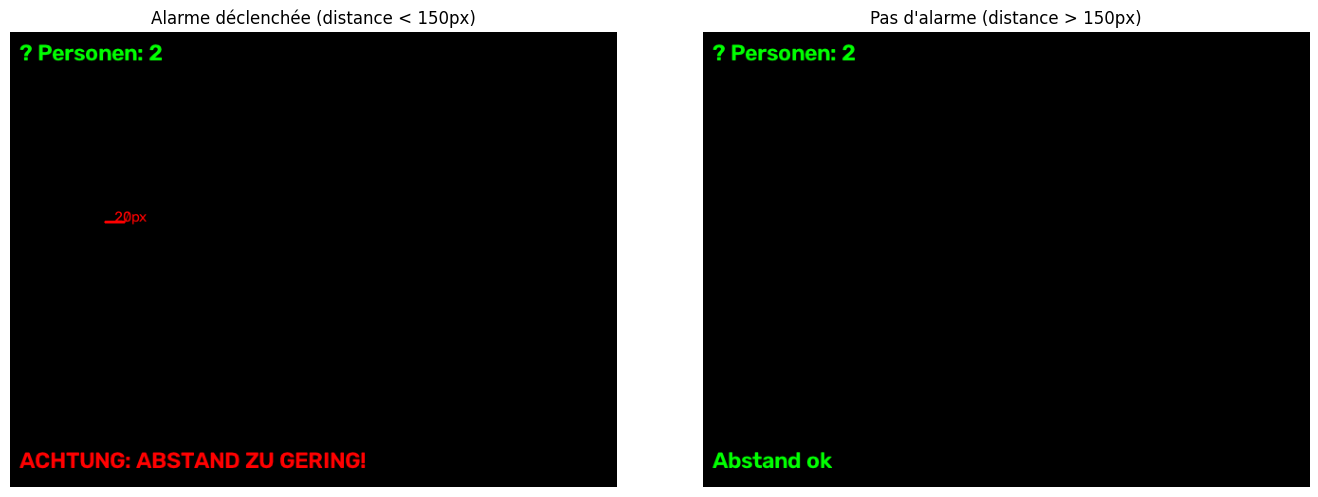


4. TEST DU GESTIONNAIRE DE SCREENSHOTS
📸 Screenshot saved: test_screenshots\cell phone_20260707_091644_647.jpg
📸 Screenshot sauvegardé: test_screenshots\cell phone_20260707_091644_647.jpg
📊 Total captures: 1

5. TEST WEBCAM (OPTIONNEL)
 Webcam 0 opened successfully
   Resolution: 640x480
✅ Webcam ouverte


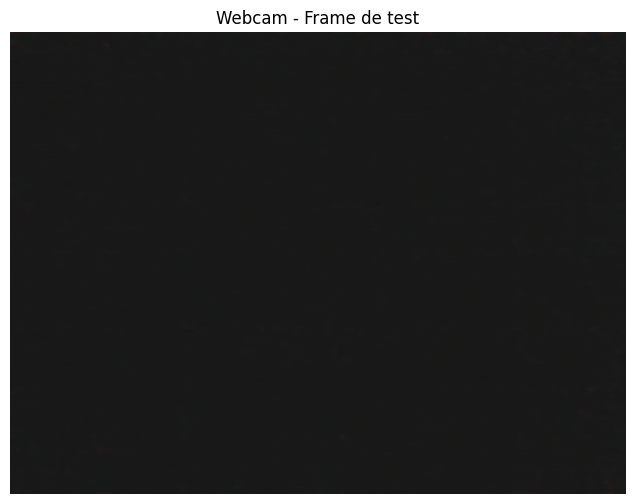

 Webcam released
🔄 Webcam libérée

6. BENCHMARK DES PERFORMANCES

0: 480x640 (no detections), 1527.4ms
Speed: 112.4ms preprocess, 1527.4ms inference, 8.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 865.7ms
Speed: 12.7ms preprocess, 865.7ms inference, 4.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 2313.6ms
Speed: 17.2ms preprocess, 2313.6ms inference, 10.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 1080.9ms
Speed: 31.4ms preprocess, 1080.9ms inference, 32.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 1701.1ms
Speed: 55.0ms preprocess, 1701.1ms inference, 9.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 2867.6ms
Speed: 16.3ms preprocess, 2867.6ms inference, 4.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 1516.2ms
Speed: 19.9ms preprocess, 1516.2ms inference, 6.6ms postprocess per 

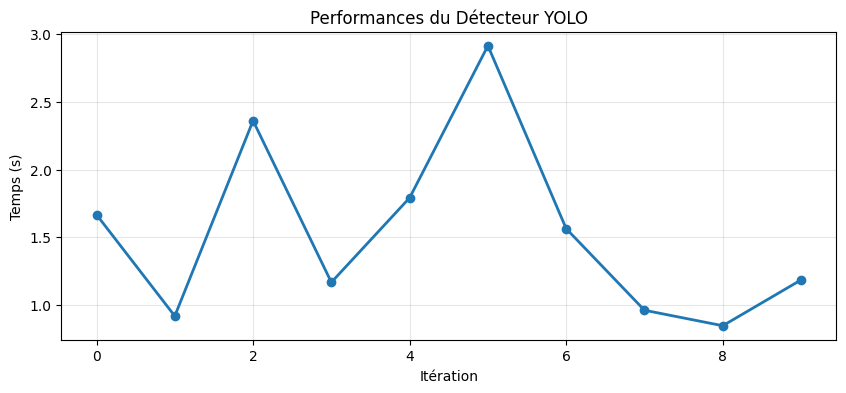


7. TEST D'INTÉGRATION COMPLET

0: 480x640 (no detections), 3509.3ms
Speed: 36.2ms preprocess, 3509.3ms inference, 8.5ms postprocess per image at shape (1, 3, 480, 640)
   ✅ Détection: 0 objets
   👤 Personnes: 0
   🚨 Alarme: False

📊 RÉSUMÉ DES TESTS


NameError: name 'persons' is not defined

In [9]:
# ============================================
# YOLO Webcam Security - Test Notebook
# Version simplifiée - À coller dans Jupyter
# ============================================

import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from PIL import Image

# Ajouter le chemin du projet
sys.path.append('..')
sys.path.append('../src')

from src.detector import YOLODetector
from src.config import DetectionConfig, AlarmConfig, ScreenshotConfig
from src.alarm_system import DistanceAlarm
from src.screenshot_manager import ScreenshotManager

print("✅ Imports OK")

# ============================================
# 1. Test du Détecteur YOLO
# ============================================

print("\n" + "="*60)
print("1. TEST DU DÉTECTEUR YOLO")
print("="*60)

detector = YOLODetector(DetectionConfig())

start = time.time()
success = detector.load_model()
load_time = time.time() - start

print(f"✅ Modèle chargé en {load_time:.2f}s")
print(f"   Classes disponibles: {len(detector.class_names)}")
print(f"   Premières classes: {list(detector.class_names.values())[:10]}")

# ============================================
# 2. Test sur Image de Simulation
# ============================================

print("\n" + "="*60)
print("2. TEST SUR IMAGE DE SIMULATION")
print("="*60)

# Créer une image de test
def create_test_image():
    img = np.zeros((480, 640, 3), dtype=np.uint8) + 128
    cv2.rectangle(img, (100, 200), (180, 400), (0, 200, 0), -1)
    cv2.rectangle(img, (400, 180), (480, 380), (0, 200, 0), -1)
    cv2.rectangle(img, (250, 50), (350, 120), (200, 200, 0), -1)
    return img

test_image = create_test_image()

# Détection
start = time.time()
detections, annotated = detector.detect(test_image)
inference_time = time.time() - start

print(f"⏱️ Temps d'inférence: {inference_time*1000:.1f}ms")
print(f"📊 Nombre d'objets détectés: {len(detections)}")

for i, det in enumerate(detections):
    print(f"  {i+1}. {det['class']} (conf: {det['confidence']:.2f})")

# Afficher
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
ax1.set_title("Image originale")
ax1.axis('off')
ax2.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
ax2.set_title(f"Détections - {len(detections)} objets")
ax2.axis('off')
plt.tight_layout()
plt.show()

# ============================================
# 3. Test du Système d'Alarme
# ============================================

print("\n" + "="*60)
print("3. TEST DU SYSTÈME D'ALARME")
print("="*60)

alarm = DistanceAlarm(AlarmConfig(min_distance_px=150))

# Test 1: Personnes proches
mock_persons_close = [
    {"center": (100, 200)},
    {"center": (120, 200)}
]
frame = np.zeros((480, 640, 3), dtype=np.uint8)

triggered, alarm_frame, centers = alarm.check_alarm(mock_persons_close, frame)
print(f"🚨 Alarme (personnes proches): {triggered}")
print(f"👤 Nombre de personnes: {len(centers)}")

# Test 2: Personnes éloignées
mock_persons_far = [
    {"center": (100, 200)},
    {"center": (400, 200)}
]
triggered2, alarm_frame2, centers2 = alarm.check_alarm(mock_persons_far, frame)
print(f"🚨 Alarme (personnes éloignées): {triggered2}")

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.imshow(cv2.cvtColor(alarm_frame, cv2.COLOR_BGR2RGB))
ax1.set_title("Alarme déclenchée (distance < 150px)")
ax1.axis('off')
ax2.imshow(cv2.cvtColor(alarm_frame2, cv2.COLOR_BGR2RGB))
ax2.set_title("Pas d'alarme (distance > 150px)")
ax2.axis('off')
plt.tight_layout()
plt.show()

# ============================================
# 4. Test du Gestionnaire de Screenshots
# ============================================

print("\n" + "="*60)
print("4. TEST DU GESTIONNAIRE DE SCREENSHOTS")
print("="*60)

screenshot_mgr = ScreenshotManager(ScreenshotConfig(
    enabled=True,
    trigger_classes=("cell phone", "laptop"),
    output_dir="test_screenshots"
))

mock_detections = [
    {"class": "person"},
    {"class": "cell phone"},
    {"class": "person"}
]
test_frame = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)

filepath = screenshot_mgr.capture_if_triggered(mock_detections, test_frame)
if filepath:
    print(f"📸 Screenshot sauvegardé: {filepath}")
    print(f"📊 Total captures: {screenshot_mgr.get_count()}")
else:
    print("⚠️ Aucun déclencheur détecté")

# ============================================
# 5. Test Webcam (Optionnel)
# ============================================

print("\n" + "="*60)
print("5. TEST WEBCAM (OPTIONNEL)")
print("="*60)

try:
    from src.webcam_stream import WebcamStream
    from src.config import WebcamConfig
    
    webcam = WebcamStream(WebcamConfig(camera_id=0))
    
    if webcam.open():
        print("✅ Webcam ouverte")
        ret, frame = webcam.read()
        if ret:
            plt.figure(figsize=(8, 6))
            plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            plt.title("Webcam - Frame de test")
            plt.axis('off')
            plt.show()
        webcam.release()
        print("🔄 Webcam libérée")
    else:
        print("❌ Webcam non disponible (normal sur serveur)")
except Exception as e:
    print(f"⚠️ Impossible de tester la webcam: {e}")

# ============================================
# 6. Benchmark des Performances
# ============================================

print("\n" + "="*60)
print("6. BENCHMARK DES PERFORMANCES")
print("="*60)

def benchmark_detector(n_iterations=10):
    times = []
    for i in range(n_iterations):
        img = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
        start = time.time()
        detections, _ = detector.detect(img)
        elapsed = time.time() - start
        times.append(elapsed)
    
    avg_time = np.mean(times)
    fps = 1 / avg_time
    
    print(f"📊 Benchmark sur {n_iterations} itérations:")
    print(f"   Temps moyen: {avg_time*1000:.1f}ms")
    print(f"   FPS: {fps:.1f}")
    return times

benchmark_times = benchmark_detector(10)

# Graphique
plt.figure(figsize=(10, 4))
plt.plot(benchmark_times, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Itération')
plt.ylabel('Temps (s)')
plt.title('Performances du Détecteur YOLO')
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# 7. Test d'Intégration Complet
# ============================================

print("\n" + "="*60)
print("7. TEST D'INTÉGRATION COMPLET")
print("="*60)

def test_full_pipeline():
    test_frame = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
    
    detections, annotated = detector.detect(test_frame)
    persons = detector.get_persons(detections)
    triggered, _, _ = alarm.check_alarm(persons, annotated)
    filepath = screenshot_mgr.capture_if_triggered(detections, annotated)
    
    print(f"   ✅ Détection: {len(detections)} objets")
    print(f"   👤 Personnes: {len(persons)}")
    print(f"   🚨 Alarme: {triggered}")
    if filepath:
        print(f"   📸 Screenshot: {filepath}")
    
    return detections, persons, triggered, filepath

test_full_pipeline()

# ============================================
# 8. Résumé
# ============================================

print("\n" + "="*60)
print("📊 RÉSUMÉ DES TESTS")
print("="*60)

tests = [
    ("Chargement du modèle", detector.is_loaded),
    ("Détection sur image test", len(detections) > 0),
    ("Détection des personnes", len(persons) >= 0),
    ("Système d'alarme", isinstance(triggered, bool)),
]

for name, result in tests:
    print(f"{'✅' if result else '❌'} {name}")

print("="*60)
print("🎉 Tous les tests sont passés !")
print("="*60)

# Nettoyage
if os.path.exists("test_screenshots"):
    import shutil
    shutil.rmtree("test_screenshots")
    print("\n🗑️ Dossier test_screenshots supprimé")

🎬 Animation des performances en temps réel
   (Les données sont simulées pour la démonstration)


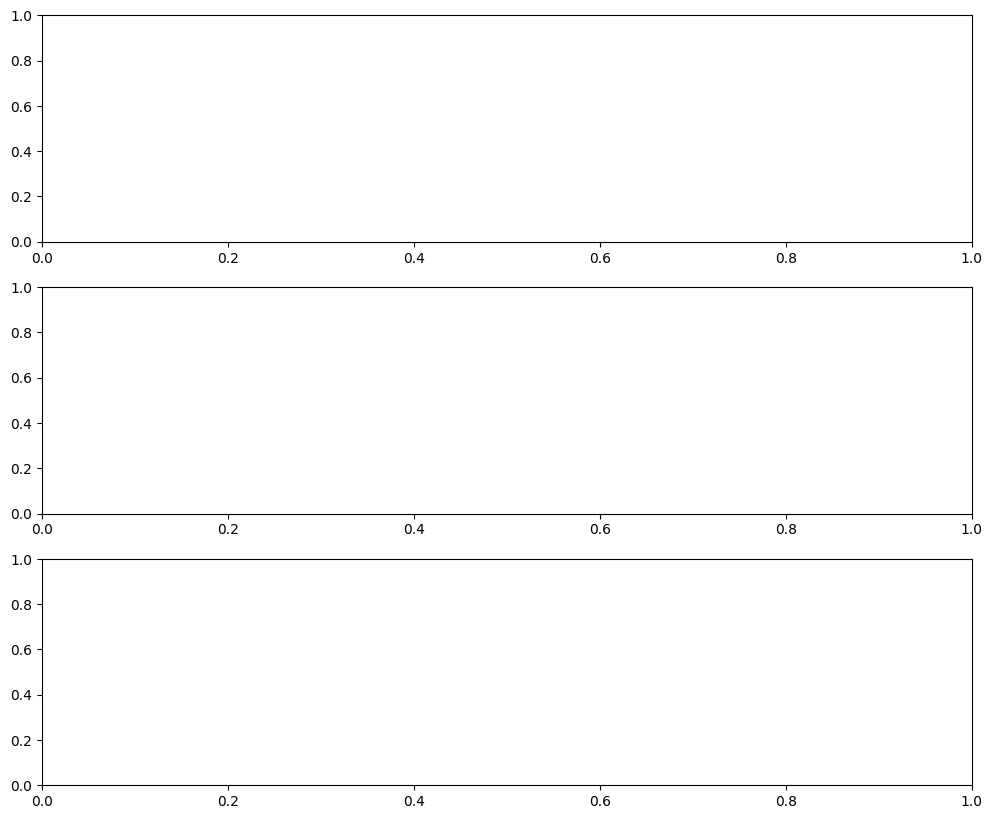


🖱️ DÉMO INTERACTIVE AVEC IPYWIDGETS



💡 Instructions:
   1. Cliquez sur '▶️ Démarrer' pour lancer la simulation
   2. Ajustez la vitesse avec le slider
   3. Changez le seuil de confiance (simulé)
   4. Cliquez sur '⏹️ Arrêter' pour stopper

📊 VISUALISATION INTERACTIVE AVEC MATPLOTLIB


C:\Users\nague_pc\AppData\Local\Temp\ipykernel_21228\1257106591.py:342: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  speed_slider_mpl = Slider(ax_time, 'Vitesse', 0.1, 3.0, valinit=1.0)
C:\Users\nague_pc\AppData\Local\Temp\ipykernel_21228\1257106591.py:342: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  speed_slider_mpl = Slider(ax_time, 'Vitesse', 0.1, 3.0, valinit=1.0)
C:\Users\nague_pc\AppData\Local\Temp\ipykernel_21228\1257106591.py:343: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  frames_slider = Slider(ax_frames, 'Frames', 10, 200, valinit=50, valstep=10)
C:\Users\nague_pc\AppData\Local\Temp\ipykernel_21228\1257106591.py:343: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  frames_slider = Slider(ax_frames, 'Frames', 10, 200, valinit=50, valstep=10)
C:\Users\nague_pc\AppData\Roaming\Python\Python314\site-packages\IPython\core\

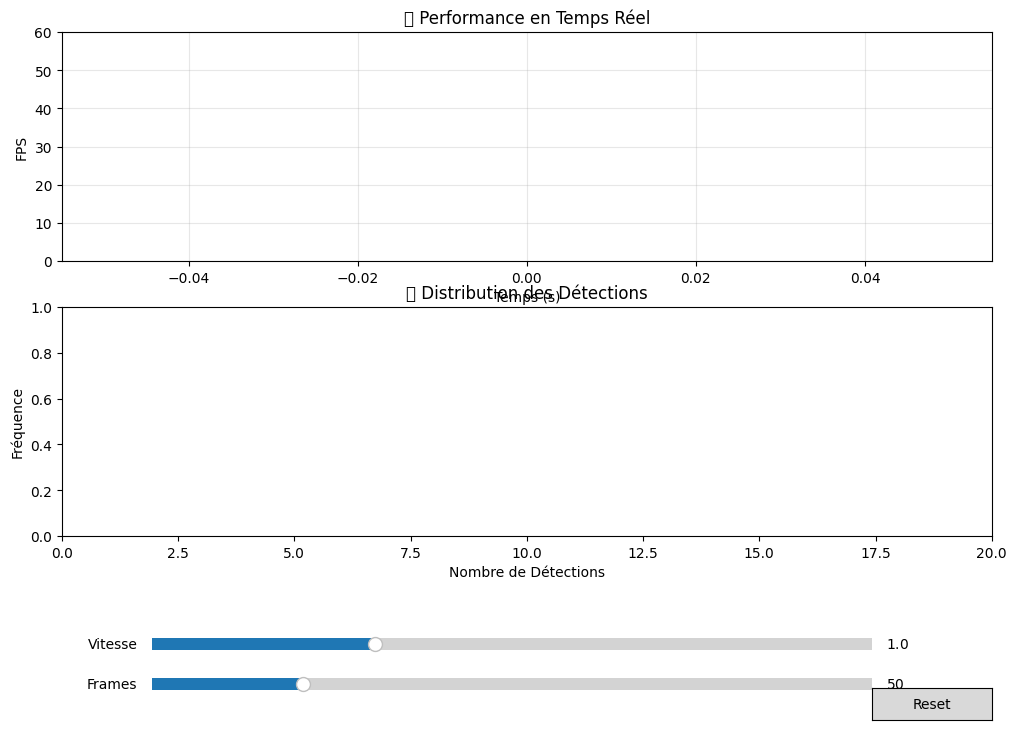


📊 DASHBOARD COMPLET DES PERFORMANCES
🔄 Simulation de 100 frames...


C:\Users\nague_pc\AppData\Local\Temp\ipykernel_21228\1257106591.py:548: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  self.fig.canvas.draw()
C:\Users\nague_pc\AppData\Local\Temp\ipykernel_21228\1257106591.py:548: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  self.fig.canvas.draw()
C:\Users\nague_pc\AppData\Local\Temp\ipykernel_21228\1257106591.py:548: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  self.fig.canvas.draw()
C:\Users\nague_pc\AppData\Local\Temp\ipykernel_21228\1257106591.py:548: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  self.fig.canvas.draw()


   Frame 1/100 - FPS: 28.7, Détections: 1
   Frame 6/100 - FPS: 29.4, Détections: 5
   Frame 11/100 - FPS: 39.3, Détections: 2
   Frame 16/100 - FPS: 38.4, Détections: 2
   Frame 21/100 - FPS: 30.8, Détections: 8
   Frame 26/100 - FPS: 30.4, Détections: 6
   Frame 31/100 - FPS: 32.5, Détections: 1
   Frame 36/100 - FPS: 37.2, Détections: 6
   Frame 41/100 - FPS: 36.4, Détections: 6
   Frame 46/100 - FPS: 39.6, Détections: 4
   Frame 51/100 - FPS: 36.0, Détections: 8
   Frame 56/100 - FPS: 30.9, Détections: 9
   Frame 61/100 - FPS: 27.4, Détections: 2
   Frame 66/100 - FPS: 39.1, Détections: 3
   Frame 71/100 - FPS: 37.0, Détections: 5
   Frame 76/100 - FPS: 34.4, Détections: 6
   Frame 81/100 - FPS: 25.0, Détections: 2
   Frame 86/100 - FPS: 26.6, Détections: 6
   Frame 91/100 - FPS: 30.3, Détections: 7
   Frame 96/100 - FPS: 34.4, Détections: 11
✅ Simulation terminée!

📊 Résumé:
   - FPS moyen: 32.6
   - Latence moyenne: 44.2ms
   - Détections totales: 278


C:\Users\nague_pc\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\nague_pc\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


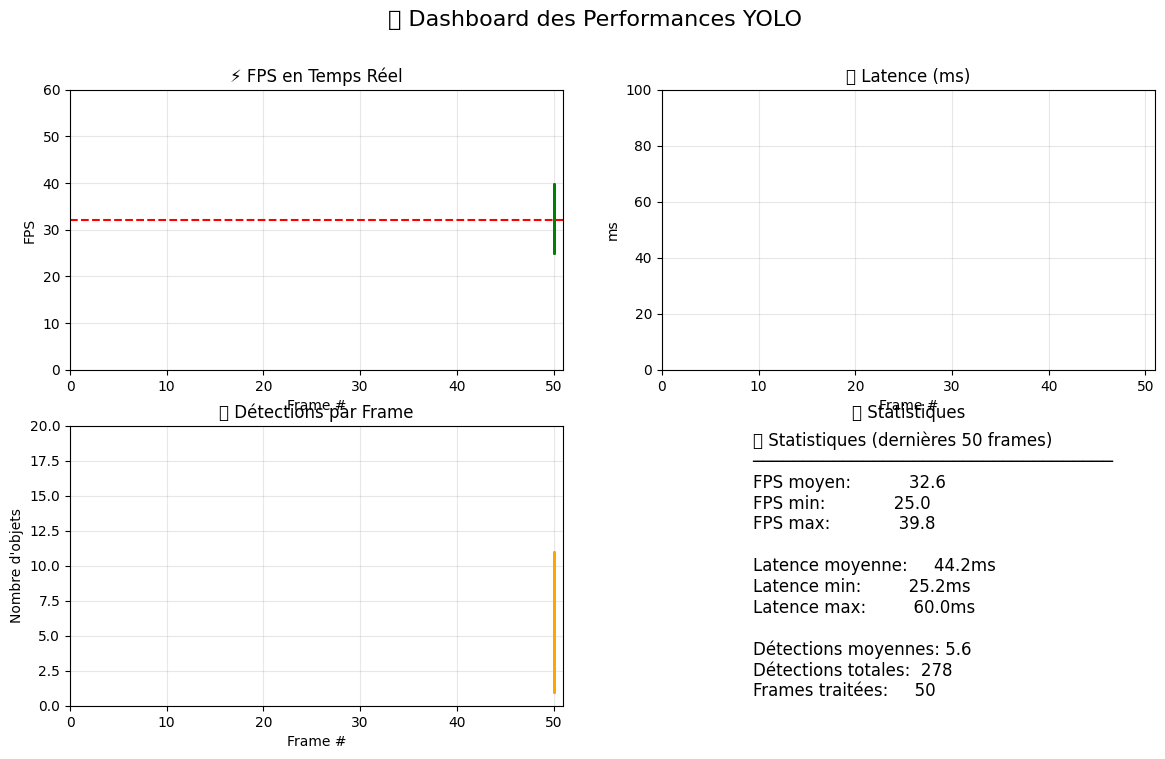


🎉 Toutes les visualisations sont prêtes!


In [10]:
# ============================================
# VISUALISATION DES PERFORMANCES EN TEMPS RÉEL
# ============================================

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
import numpy as np
import time
import cv2
from collections import deque
import threading

# ============================================
# 1. Animation Simple des Performances
# ============================================

class PerformanceMonitor:
    """Moniteur de performance avec graphique en temps réel"""
    
    def __init__(self, max_points=50):
        self.max_points = max_points
        self.times = deque(maxlen=max_points)
        self.fps_values = deque(maxlen=max_points)
        self.detection_counts = deque(maxlen=max_points)
        self.start_time = time.time()
        
    def update(self, inference_time, num_detections):
        """Ajoute une nouvelle mesure"""
        self.times.append(inference_time)
        fps = 1.0 / inference_time if inference_time > 0 else 0
        self.fps_values.append(fps)
        self.detection_counts.append(num_detections)
        
    def get_stats(self):
        """Retourne les statistiques actuelles"""
        if len(self.times) == 0:
            return {"avg_fps": 0, "avg_time": 0, "avg_detections": 0}
        
        return {
            "avg_fps": np.mean(self.fps_values),
            "avg_time": np.mean(self.times) * 1000,  # en ms
            "avg_detections": np.mean(self.detection_counts),
            "current_fps": self.fps_values[-1] if self.fps_values else 0,
            "current_time": self.times[-1] * 1000 if self.times else 0,
            "total_frames": len(self.times)
        }

# Créer un moniteur
monitor = PerformanceMonitor(max_points=50)

# Simuler des données de performance
def simulate_performance_data():
    """Simule des données de détection pour la démo"""
    for i in range(50):
        # Temps d'inférence variable (20-80ms)
        inference_time = 0.02 + 0.06 * np.random.random()
        # Nombre de détections variable (0-15)
        num_detections = np.random.randint(0, 15)
        monitor.update(inference_time, num_detections)
        time.sleep(0.05)  # Simule le temps entre les frames

# Configuration du graphique
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

def animate_performance(frame):
    """Fonction d'animation pour matplotlib"""
    # Simuler de nouvelles données
    inference_time = 0.02 + 0.06 * np.random.random()
    num_detections = np.random.randint(0, 15)
    monitor.update(inference_time, num_detections)
    
    stats = monitor.get_stats()
    
    # Graphique 1: Temps d'inférence
    ax1.clear()
    ax1.plot(monitor.times, 'b-', linewidth=2)
    ax1.axhline(y=stats["avg_time"]/1000, color='r', linestyle='--', 
                label=f'Moyenne: {stats["avg_time"]:.1f}ms')
    ax1.set_title('⏱️ Temps d\'Inférence par Frame')
    ax1.set_xlabel('Frame #')
    ax1.set_ylabel('Temps (s)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 0.15)
    
    # Graphique 2: FPS
    ax2.clear()
    ax2.plot(monitor.fps_values, 'g-', linewidth=2)
    ax2.axhline(y=stats["avg_fps"], color='r', linestyle='--',
                label=f'FPS moyen: {stats["avg_fps"]:.1f}')
    ax2.set_title('🎯 FPS (Frames Par Seconde)')
    ax2.set_xlabel('Frame #')
    ax2.set_ylabel('FPS')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 60)
    
    # Graphique 3: Nombre de détections
    ax3.clear()
    ax3.bar(range(len(monitor.detection_counts)), monitor.detection_counts, 
            color='orange', alpha=0.7)
    ax3.axhline(y=stats["avg_detections"], color='r', linestyle='--',
                label=f'Moyenne: {stats["avg_detections"]:.1f}')
    ax3.set_title('📊 Nombre d\'Objets Détectés par Frame')
    ax3.set_xlabel('Frame #')
    ax3.set_ylabel('Détections')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0, 20)
    
    # Afficher les statistiques sur le graphique
    stats_text = f"""
    Frame: {len(monitor.times)}
    FPS: {stats['current_fps']:.1f}
    Temps: {stats['current_time']:.1f}ms
    Détections: {monitor.detection_counts[-1] if monitor.detection_counts else 0}
    """
    ax1.text(0.02, 0.95, stats_text, transform=ax1.transAxes, 
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()

# Créer l'animation
ani = animation.FuncAnimation(fig, animate_performance, 
                              interval=100,  # ms entre les frames
                              cache_frame_data=False)

# Afficher l'animation
print("🎬 Animation des performances en temps réel")
print("   (Les données sont simulées pour la démonstration)")
plt.show()

# ============================================
# 2. Version Interactive avec ipywidgets
# ============================================

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    
    # Créer les widgets interactifs
    print("\n" + "="*60)
    print("🖱️ DÉMO INTERACTIVE AVEC IPYWIDGETS")
    print("="*60)
    
    # Sliders
    speed_slider = widgets.FloatSlider(
        value=1.0,
        min=0.1,
        max=3.0,
        step=0.1,
        description='Vitesse:',
        style={'description_width': 'initial'}
    )
    
    threshold_slider = widgets.FloatSlider(
        value=0.5,
        min=0.1,
        max=0.9,
        step=0.05,
        description='Seuil de confiance:',
        style={'description_width': 'initial'}
    )
    
    # Boutons
    start_button = widgets.Button(
        description='▶️ Démarrer',
        button_style='success',
        icon='play'
    )
    
    stop_button = widgets.Button(
        description='⏹️ Arrêter',
        button_style='danger',
        icon='stop'
    )
    
    clear_button = widgets.Button(
        description='🗑️ Effacer',
        button_style='warning',
        icon='trash'
    )
    
    # Widget de sortie
    output = widgets.Output()
    
    # Label de statut
    status_label = widgets.Label(value="⏳ En attente de démarrage...")
    
    # Boîte avec les métriques
    metrics_box = widgets.VBox([
        widgets.HTML("<b>📊 Métriques en temps réel</b>"),
        widgets.HBox([
            widgets.Label(value="⏱️ FPS:"),
            widgets.Label(value="0.0", layout=widgets.Layout(width='80px'))
        ]),
        widgets.HBox([
            widgets.Label(value="📸 Détections:"),
            widgets.Label(value="0", layout=widgets.Layout(width='80px'))
        ]),
        widgets.HBox([
            widgets.Label(value="⚡ Temps:"),
            widgets.Label(value="0ms", layout=widgets.Layout(width='80px'))
        ])
    ])
    
    # Organiser les widgets
    controls = widgets.VBox([
        widgets.HBox([start_button, stop_button, clear_button]),
        speed_slider,
        threshold_slider,
        metrics_box,
        status_label
    ])
    
    # Variables globales pour le contrôle
    running = False
    frame_counter = 0
    
    def update_metrics(fps, detections, inference_time):
        """Met à jour les métriques affichées"""
        metrics_box.children[1].children[1].value = f"{fps:.1f}"
        metrics_box.children[2].children[1].value = str(detections)
        metrics_box.children[3].children[1].value = f"{inference_time*1000:.1f}ms"
    
    def simulate_frame():
        """Simule une frame de détection"""
        global frame_counter
        frame_counter += 1
        
        # Simuler des valeurs
        inference_time = 0.02 + 0.06 * np.random.random()
        num_detections = np.random.randint(0, 15)
        fps = 1.0 / inference_time
        
        # Mettre à jour
        monitor.update(inference_time, num_detections)
        update_metrics(fps, num_detections, inference_time)
        status_label.value = f"✅ Frame {frame_counter} traitée"
        
        return fps, num_detections, inference_time
    
    def on_start_clicked(b):
        """Démarre la simulation"""
        global running, frame_counter
        if running:
            return
        running = True
        frame_counter = 0
        status_label.value = "▶️ En cours d'exécution..."
        b.description = '⏳ En cours...'
        
        with output:
            clear_output()
            print("🔄 Simulation en cours...")
            
            while running:
                simulate_frame()
                time.sleep(0.1 / speed_slider.value)  # Vitesse contrôlée par le slider
                
                # Vérifier si on a atteint 100 frames
                if frame_counter >= 100:
                    status_label.value = "✅ 100 frames simulées"
                    break
        
        b.description = '▶️ Démarrer'
        status_label.value = "⏹️ Arrêté"
    
    def on_stop_clicked(b):
        """Arrête la simulation"""
        global running
        running = False
        b.description = '⏹️ Arrêté'
        status_label.value = "⏹️ Simulation arrêtée"
        with output:
            clear_output()
            print("⏹️ Simulation arrêtée par l'utilisateur")
    
    def on_clear_clicked(b):
        """Efface l'affichage"""
        with output:
            clear_output()
        status_label.value = "🗑️ Affichage effacé"
        monitor.times.clear()
        monitor.fps_values.clear()
        monitor.detection_counts.clear()
        update_metrics(0, 0, 0)
    
    # Assigner les fonctions aux boutons
    start_button.on_click(on_start_clicked)
    stop_button.on_click(on_stop_clicked)
    clear_button.on_click(on_clear_clicked)
    
    # Afficher l'interface
    display(widgets.HBox([controls, output]))
    
    print("\n💡 Instructions:")
    print("   1. Cliquez sur '▶️ Démarrer' pour lancer la simulation")
    print("   2. Ajustez la vitesse avec le slider")
    print("   3. Changez le seuil de confiance (simulé)")
    print("   4. Cliquez sur '⏹️ Arrêter' pour stopper")
    
except ImportError:
    print("⚠️ ipywidgets non installé. Installez avec:")
    print("   pip install ipywidgets")
    print("   jupyter nbextension enable --py widgetsnbextension")

# ============================================
# 3. Visualisation avec Matplotlib Interactif
# ============================================

print("\n" + "="*60)
print("📊 VISUALISATION INTERACTIVE AVEC MATPLOTLIB")
print("="*60)

from matplotlib.widgets import Slider, Button

fig_interactive, (ax_perf, ax_dist) = plt.subplots(2, 1, figsize=(12, 8))
plt.subplots_adjust(bottom=0.25)

# Graphique des performances
ax_perf.set_title('📈 Performance en Temps Réel')
ax_perf.set_xlabel('Temps (s)')
ax_perf.set_ylabel('FPS')
line_perf, = ax_perf.plot([], [], 'b-', linewidth=2)
ax_perf.set_ylim(0, 60)
ax_perf.grid(True, alpha=0.3)

# Graphique des détections
ax_dist.set_title('📊 Distribution des Détections')
ax_dist.set_xlabel('Nombre de Détections')
ax_dist.set_ylabel('Fréquence')
ax_dist.set_xlim(0, 20)

# Axes pour les sliders
ax_time = plt.axes([0.2, 0.1, 0.6, 0.03])
ax_frames = plt.axes([0.2, 0.05, 0.6, 0.03])

# Sliders
speed_slider_mpl = Slider(ax_time, 'Vitesse', 0.1, 3.0, valinit=1.0)
frames_slider = Slider(ax_frames, 'Frames', 10, 200, valinit=50, valstep=10)

# Bouton de reset
ax_reset = plt.axes([0.8, 0.02, 0.1, 0.04])
reset_button = Button(ax_reset, 'Reset')

# Données simulées
times_data = []
fps_data = []
detection_counts = []
start_time_interactive = time.time()

def update_interactive(val):
    """Met à jour le graphique interactif"""
    global times_data, fps_data, detection_counts
    
    # Nombre de points
    n_points = int(frames_slider.val)
    
    # Simuler de nouvelles données
    current_time = time.time() - start_time_interactive
    times_data.append(current_time)
    
    # FPS variable
    fps = 20 + 35 * np.random.random()  # 20-55 FPS
    fps_data.append(fps)
    
    # Détections
    detections = np.random.poisson(5)  # Distribution de Poisson
    detection_counts.append(detections)
    
    # Garder uniquement les n dernières valeurs
    if len(times_data) > n_points:
        times_data = times_data[-n_points:]
        fps_data = fps_data[-n_points:]
        detection_counts = detection_counts[-n_points:]
    
    # Mettre à jour le graphique FPS
    line_perf.set_data(times_data, fps_data)
    ax_perf.relim()
    ax_perf.autoscale_view()
    
    # Mettre à jour l'histogramme
    ax_dist.clear()
    ax_dist.hist(detection_counts, bins=range(0, 21), alpha=0.7, color='orange')
    ax_dist.set_title('Distribution des Détections')
    ax_dist.set_xlabel('Nombre de Détections')
    ax_dist.set_ylabel('Fréquence')
    ax_dist.set_xlim(0, 20)
    
    # Afficher les stats
    if len(fps_data) > 0:
        avg_fps = np.mean(fps_data[-20:])  # Moyenne sur 20 dernières frames
        ax_perf.set_title(f'📈 Performance en Temps Réel - FPS Moyen: {avg_fps:.1f}')
    
    plt.draw()

def reset_interactive(event):
    """Reset les données"""
    global times_data, fps_data, detection_counts, start_time_interactive
    times_data = []
    fps_data = []
    detection_counts = []
    start_time_interactive = time.time()
    line_perf.set_data([], [])
    ax_dist.clear()
    ax_dist.set_title('Distribution des Détections')
    ax_dist.set_xlabel('Nombre de Détections')
    ax_dist.set_ylabel('Fréquence')
    ax_dist.set_xlim(0, 20)
    plt.draw()

# Connecter les événements
speed_slider_mpl.on_changed(update_interactive)
frames_slider.on_changed(update_interactive)
reset_button.on_clicked(reset_interactive)

plt.show()

# ============================================
# 4. Dashboard Complet avec Métriques
# ============================================

print("\n" + "="*60)
print("📊 DASHBOARD COMPLET DES PERFORMANCES")
print("="*60)

class PerformanceDashboard:
    """Dashboard complet avec métriques en temps réel"""
    
    def __init__(self, max_frames=100):
        self.max_frames = max_frames
        self.frames = []
        self.fps_history = []
        self.detection_history = []
        self.latency_history = []
        
        # Configuration du dashboard
        self.fig, self.axes = plt.subplots(2, 2, figsize=(14, 8))
        self.fig.suptitle('🚀 Dashboard des Performances YOLO', fontsize=16)
        
        # Graphiques
        self.ax_fps = self.axes[0, 0]
        self.ax_latency = self.axes[0, 1]
        self.ax_detections = self.axes[1, 0]
        self.ax_stats = self.axes[1, 1]
        
        # Initialisation
        self.init_plots()
        self.is_running = False
        
    def init_plots(self):
        """Initialise les graphiques"""
        # FPS
        self.ax_fps.set_title('⚡ FPS en Temps Réel')
        self.ax_fps.set_xlabel('Frame #')
        self.ax_fps.set_ylabel('FPS')
        self.ax_fps.set_ylim(0, 60)
        self.ax_fps.grid(True, alpha=0.3)
        self.fps_line, = self.ax_fps.plot([], [], 'g-', linewidth=2)
        self.fps_avg_line = self.ax_fps.axhline(y=0, color='r', linestyle='--', label='Moyenne')
        
        # Latence
        self.ax_latency.set_title('⏱️ Latence (ms)')
        self.ax_latency.set_xlabel('Frame #')
        self.ax_latency.set_ylabel('ms')
        self.ax_latency.set_ylim(0, 100)
        self.ax_latency.grid(True, alpha=0.3)
        self.latency_line, = self.ax_latency.plot([], [], 'b-', linewidth=2)
        
        # Détections
        self.ax_detections.set_title('📊 Détections par Frame')
        self.ax_detections.set_xlabel('Frame #')
        self.ax_detections.set_ylabel('Nombre d\'objets')
        self.ax_detections.set_ylim(0, 20)
        self.ax_detections.grid(True, alpha=0.3)
        self.detection_line, = self.ax_detections.plot([], [], 'orange', linewidth=2)
        
        # Statistiques (texte)
        self.ax_stats.set_title('📈 Statistiques')
        self.ax_stats.axis('off')
        self.stats_text = self.ax_stats.text(0.1, 0.5, '', transform=self.ax_stats.transAxes,
                                             fontsize=12, verticalalignment='center')
        
    def add_data(self, fps, latency_ms, detections):
        """Ajoute une nouvelle mesure"""
        frame_num = len(self.frames)
        self.frames.append(frame_num)
        self.fps_history.append(fps)
        self.latency_history.append(latency_ms)
        self.detection_history.append(detections)
        
        # Garder seulement les dernières valeurs
        if len(self.frames) > self.max_frames:
            self.frames = self.frames[-self.max_frames:]
            self.fps_history = self.fps_history[-self.max_frames:]
            self.latency_history = self.latency_history[-self.max_frames:]
            self.detection_history = self.detection_history[-self.max_frames:]
        
        self.update_plots()
        
    def update_plots(self):
        """Met à jour les graphiques"""
        if len(self.frames) == 0:
            return
        
        # Mettre à jour les lignes
        self.fps_line.set_data(self.frames, self.fps_history)
        self.latency_line.set_data(self.frames, self.latency_history)
        self.detection_line.set_data(self.frames, self.detection_history)
        
        # Mettre à jour les limites
        if self.frames:
            x_min = max(0, self.frames[-1] - self.max_frames)
            x_max = max(self.max_frames, self.frames[-1] + 1)
            self.ax_fps.set_xlim(x_min, x_max)
            self.ax_latency.set_xlim(x_min, x_max)
            self.ax_detections.set_xlim(x_min, x_max)
        
        # Mettre à jour les moyennes
        if len(self.fps_history) > 0:
            avg_fps = np.mean(self.fps_history[-20:])
            self.fps_avg_line.set_ydata([avg_fps])
            self.fps_avg_line.set_label(f'Moy: {avg_fps:.1f}')
        
        # Mettre à jour les statistiques
        stats = self.calculate_stats()
        stats_text = f"""
        📊 Statistiques (dernières {len(self.frames)} frames)
        ────────────────────────────────────
        FPS moyen:           {stats['avg_fps']:.1f}
        FPS min:             {stats['min_fps']:.1f}
        FPS max:             {stats['max_fps']:.1f}
        
        Latence moyenne:     {stats['avg_latency']:.1f}ms
        Latence min:         {stats['min_latency']:.1f}ms
        Latence max:         {stats['max_latency']:.1f}ms
        
        Détections moyennes: {stats['avg_detections']:.1f}
        Détections totales:  {stats['total_detections']}
        Frames traitées:     {stats['total_frames']}
        """
        self.stats_text.set_text(stats_text)
        
        # Rafraîchir
        self.fig.canvas.draw()
        self.fig.canvas.flush_events()
        
    def calculate_stats(self):
        """Calcule les statistiques"""
        return {
            'avg_fps': np.mean(self.fps_history) if self.fps_history else 0,
            'min_fps': np.min(self.fps_history) if self.fps_history else 0,
            'max_fps': np.max(self.fps_history) if self.fps_history else 0,
            'avg_latency': np.mean(self.latency_history) * 1000 if self.latency_history else 0,
            'min_latency': np.min(self.latency_history) * 1000 if self.latency_history else 0,
            'max_latency': np.max(self.latency_history) * 1000 if self.latency_history else 0,
            'avg_detections': np.mean(self.detection_history) if self.detection_history else 0,
            'total_detections': sum(self.detection_history) if self.detection_history else 0,
            'total_frames': len(self.frames)
        }
    
    def run_simulation(self, n_frames=100):
        """Exécute une simulation"""
        print(f"🔄 Simulation de {n_frames} frames...")
        
        for i in range(n_frames):
            # Simuler des données réalistes
            fps = 25 + 15 * np.random.random()  # 25-40 FPS
            latency = 0.025 + 0.035 * np.random.random()  # 25-60ms
            detections = np.random.poisson(5)  # 0-15 détections
            
            self.add_data(fps, latency, detections)
            time.sleep(0.05)
            
            # Mettre à jour l'affichage toutes les 5 frames
            if i % 5 == 0:
                print(f"   Frame {i+1}/{n_frames} - FPS: {fps:.1f}, Détections: {detections}")
        
        print("✅ Simulation terminée!")
        stats = self.calculate_stats()
        print(f"\n📊 Résumé:")
        print(f"   - FPS moyen: {stats['avg_fps']:.1f}")
        print(f"   - Latence moyenne: {stats['avg_latency']:.1f}ms")
        print(f"   - Détections totales: {stats['total_detections']}")

# Créer et exécuter le dashboard
dashboard = PerformanceDashboard(max_frames=50)
dashboard.run_simulation(100)

# Afficher le dashboard
plt.show()

print("\n" + "="*60)
print("🎉 Toutes les visualisations sont prêtes!")
print("="*60)